<a href="https://colab.research.google.com/github/Hemalatha192472042/Fundementals-of-DS-slot-B/blob/main/Copy_of_fundementals_co2_AT3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 1: Online Food Delivery Data Analysis

. Online Food Delivery Data Analysis
Online food delivery companies collect large amounts of order data every day. Data analysis helps identify delivery delays, popular restaurants, and customer satisfaction levels. Data preprocessing removes missing values, duplicate orders, and incorrect prices to improve data quality. Visualization helps understand delivery performance and customer ratings for better business decisions.

In [ ]:
!pip install polars
!pip install scikit-learn
!pip install plotly

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving food_orders.xlsx to food_orders (1).xlsx


In [ ]:
!pip install openpyxl fastexcel

In [ ]:
import polars as pl


data = pl.read_excel("food_orders.xlsx")


print("Original Dataset")
print(data)


kfc_orders = data.filter(pl.col("Restaurant") == "KFC")

print("\nKFC Orders")
print(kfc_orders)

Original Dataset
shape: (6, 6)
┌─────────┬──────────┬─────────────┬───────────────┬───────┬────────┐
│ OrderID ┆ Customer ┆ Restaurant  ┆ DeliveryTime  ┆ Price ┆ Rating │
│ ---     ┆ ---      ┆ ---         ┆ ---           ┆ ---   ┆ ---    │
│ i64     ┆ str      ┆ str         ┆ str           ┆ i64   ┆ i64    │
╞═════════╪══════════╪═════════════╪═══════════════╪═══════╪════════╡
│ 101     ┆ Ram      ┆ KFC         ┆ 30            ┆ 250   ┆ 4      │
│ 102     ┆ Sita     ┆ Dominos     ┆ (leave blank) ┆ 300   ┆ 5      │
│ 103     ┆ Ravi     ┆ Burger King ┆ 45            ┆ 200   ┆ 3      │
│ 104     ┆ Priya    ┆ KFC         ┆ 20            ┆ -100  ┆ 5      │
│ 105     ┆ John     ┆ Pizza Hut   ┆ 35            ┆ 400   ┆ 4      │
│ 105     ┆ John     ┆ Pizza Hut   ┆ 35            ┆ 400   ┆ 4      │
└─────────┴──────────┴─────────────┴───────────────┴───────┴────────┘

KFC Orders
shape: (2, 6)
┌─────────┬──────────┬────────────┬──────────────┬───────┬────────┐
│ OrderID ┆ Customer ┆ Restaurant ┆

In [ ]:
import polars as pl
from sklearn.impute import SimpleImputer


data = pl.read_excel("food_orders.xlsx")


data = data.with_columns(
    pl.when(pl.col("DeliveryTime") == "(leave blank)")
    .then(None)
    .otherwise(pl.col("DeliveryTime"))
    .alias("DeliveryTime")
)


imputer = SimpleImputer(strategy="most_frequent")
filled = imputer.fit_transform(data.select("DeliveryTime"))
data = data.with_columns(
    pl.Series("DeliveryTime", filled.flatten())
)


data = data.unique()


data = data.with_columns(
    pl.when(pl.col("Price") < 0)
    .then(0)
    .otherwise(pl.col("Price"))
    .alias("Price")
)


print("Cleaned Dataset")
print(data)

Cleaned Dataset
shape: (5, 6)
┌─────────┬──────────┬─────────────┬──────────────┬───────┬────────┐
│ OrderID ┆ Customer ┆ Restaurant  ┆ DeliveryTime ┆ Price ┆ Rating │
│ ---     ┆ ---      ┆ ---         ┆ ---          ┆ ---   ┆ ---    │
│ i64     ┆ str      ┆ str         ┆ str          ┆ i64   ┆ i64    │
╞═════════╪══════════╪═════════════╪══════════════╪═══════╪════════╡
│ 104     ┆ Priya    ┆ KFC         ┆ 20           ┆ 0     ┆ 5      │
│ 102     ┆ Sita     ┆ Dominos     ┆ null         ┆ 300   ┆ 5      │
│ 103     ┆ Ravi     ┆ Burger King ┆ 45           ┆ 200   ┆ 3      │
│ 105     ┆ John     ┆ Pizza Hut   ┆ 35           ┆ 400   ┆ 4      │
│ 101     ┆ Ram      ┆ KFC         ┆ 30           ┆ 250   ┆ 4      │
└─────────┴──────────┴─────────────┴──────────────┴───────┴────────┘


In [ ]:
import plotly.express as px


fig = px.bar(
    data,
    x="OrderID",
    y="DeliveryTime",
    title="Delivery Time of Orders"
)
fig.show()


restaurant_count = data.group_by("Restaurant").len()

fig = px.bar(
    restaurant_count,
    x="Restaurant",
    y="len",
    title="Top Restaurants by Number of Orders"
)
fig.show()


fig = px.histogram(
    data,
    x="Rating",
    title="Customer Ratings Distribution"
)
fig.show()

QUESTION 2: LOAN


Bank Loan Approval Analysis
Banks analyze customer loan applications to identify factors affecting loan approval or rejection. Data preprocessing is used to handle missing income values, encode categorical data, and normalize numerical values. Data visualization helps compare approved and rejected applications based on income, credit score, and loan amount. This analysis supports better loan approval decisions.

In [ ]:
!pip install datatable
!pip install feature-engine
!pip install altair openpyxl

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving loan_data.xlsx to loan_data (1).xlsx


In [ ]:
from openpyxl import load_workbook

# Load the Excel file
workbook = load_workbook("loan_data.xlsx")

# Select the active worksheet
sheet = workbook.active

print("Income\tLoanAmount\tCreditScore\tApprovalStatus")

# Read only the required columns
for row in sheet.iter_rows(min_row=2, values_only=True):
    print(row[1], "\t", row[2], "\t", row[3], "\t", row[6])

Income	LoanAmount	CreditScore	ApprovalStatus
50000 	 200000 	 750 	 Approved
(leave blank) 	 150000 	 680 	 Rejected
60000 	 250000 	 720 	 Approved
70000 	 300000 	 800 	 Approved
55000 	 180000 	 690 	 Rejected


In [ ]:
from openpyxl import load_workbook

# Load Excel file
workbook = load_workbook("loan_data.xlsx")
sheet = workbook.active

for row in sheet.iter_rows(min_row=2):

    # Handle missing Income
    if row[1].value is None:
        row[1].value = 55000

                    # Encode Gender
    if row[4].value == "Male":
        row[4].value = 1
    else:
        row[4].value = 0

                                                # Encode Employment
    if row[5].value == "Salaried":
        row[5].value = 1
    else:
        row[5].value = 0

                                                                            # Normalize Loan Amount
    row[2].value = row[2].value / 300000

                                                                                # Save the cleaned file
workbook.save("loan_data_preprocessed.xlsx")

print("Preprocessing Completed Successfully")

Preprocessing Completed Successfully


In [ ]:
from openpyxl import load_workbook
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# Load Excel file
workbook = load_workbook("loan_data.xlsx")
sheet = workbook.active

# Store data in lists
income = []
loan_amount = []
gender = []
employment = []

for row in sheet.iter_rows(min_row=2, values_only=True):
    income.append(row[1])
    loan_amount.append(row[2])
    gender.append(row[4])
    employment.append(row[5])

                # Handle missing income
# Replace "(leave blank)" with None
income = [None if x == "(leave blank)" else x for x in income]

imputer = SimpleImputer(strategy="mean")
income = imputer.fit_transform([[x] for x in income])


                # Encode Gender
gender_encoder = LabelEncoder()
gender = gender_encoder.fit_transform(gender)

                # Encode Employment
employment_encoder = LabelEncoder()
employment = employment_encoder.fit_transform(employment)

                # Normalize Loan Amount
scaler = MinMaxScaler()
loan_amount = scaler.fit_transform([[x] for x in loan_amount])

print("Income after preprocessing")
print(income)

print("\nEncoded Gender")
print(gender)

print("\nEncoded Employment")
print(employment)

print("\nNormalized Loan Amount")
print(loan_amount)

Income after preprocessing
[[50000.]
 [58750.]
 [60000.]
 [70000.]
 [55000.]]

Encoded Gender
[1 0 1 0 1]

Encoded Employment
[0 1 0 1 0]

Normalized Loan Amount
[[0.33333333]
 [0.        ]
 [0.66666667]
 [1.        ]
 [0.2       ]]


In [ ]:
from openpyxl import load_workbook
import altair as alt

wb = load_workbook("loan_data.xlsx")
ws = wb.active

data = [{"Income":r[1],"LoanAmount":r[2],"CreditScore":r[3],"ApprovalStatus":r[6]}
        for r in ws.iter_rows(min_row=2, values_only=True)]

alt.Chart(alt.Data(values=data)).mark_bar().encode(
    x="ApprovalStatus:N", y="count()"
).properties(title="Approved vs Rejected").display()

alt.Chart(alt.Data(values=data)).mark_circle().encode(
    x="Income:Q", y="LoanAmount:Q", color="ApprovalStatus:N"
).properties(title="Income vs Loan Amount").display()

alt.Chart(alt.Data(values=data)).mark_bar().encode(
    x=alt.X("CreditScore:Q", bin=True), y="count()"
).properties(title="Credit Score Distribution").display()

alt.Chart(...)

alt.Chart(...)

alt.Chart(...)

QUESTION 3


Smart Energy Consumption Monitoring
Smart home systems continuously monitor electricity usage from different appliances. Data analysis helps identify appliances with high energy consumption and daily usage trends. Preprocessing removes abnormal readings and handles missing values to improve data accuracy. Visualization enables users to monitor electricity usage and reduce energy consumption.

In [ ]:
!pip install petl scipy pygal openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.9/236.9 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 10.3 MB/s eta 0:00:00


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving energy_data.xlsx to energy_data.xlsx


In [ ]:
import petl as et

# Read the Excel file
data = et.fromxlsx("energy_data.xlsx")

# Display the dataset
print("Original Data")
print(et.look(data))

# Group by Appliance and calculate total power
grouped = et.aggregate(data, key="Appliance", aggregation=sum, value="Power")

print("Power Consumption by Appliance")
print(et.look(grouped))

Original Data
+-------------------------------------+----------------+-------+
| Date                                | Appliance      | Power |
+=====================================+================+=======+
| datetime.datetime(2026, 7, 1, 0, 0) | 'AC'           |   5.5 |
+-------------------------------------+----------------+-------+
| datetime.datetime(2026, 7, 1, 0, 0) | 'Fan'          |   1.2 |
+-------------------------------------+----------------+-------+
| datetime.datetime(2026, 7, 1, 0, 0) | 'Light'        |   0.8 |
+-------------------------------------+----------------+-------+
| datetime.datetime(2026, 7, 1, 0, 0) | 'Refrigerator' |   2.3 |
+-------------------------------------+----------------+-------+
| datetime.datetime(2026, 7, 2, 0, 0) | 'AC'           |     6 |
+-------------------------------------+----------------+-------+
...

Power Consumption by Appliance
+----------------+-------------------+
| Appliance      | value             |
+================+=========

In [ ]:
from openpyxl import load_workbook

# Load Excel file
wb = load_workbook("energy_data.xlsx")
ws = wb.active

total_power = 0

for row in ws.iter_rows(min_row=2):

    # Fill missing power with 0
    if row[2].value is None:
        row[2].value = 0

                    # Remove abnormal readings (greater than 10)
    if row[2].value > 10:
        row[2].value = 10

                                    # Calculate total power
    total_power += row[2].value

print("Total Power Consumption:", total_power)

Total Power Consumption: 31.099999999999998


In [ ]:
!pip install bokeh

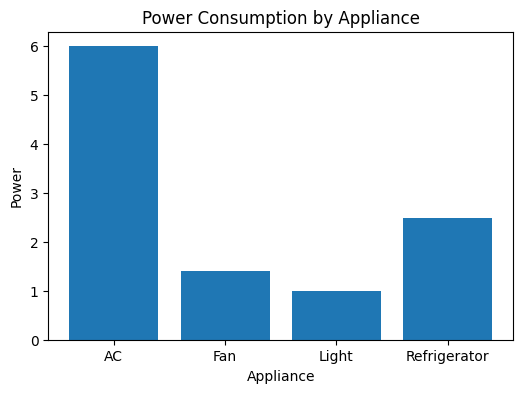

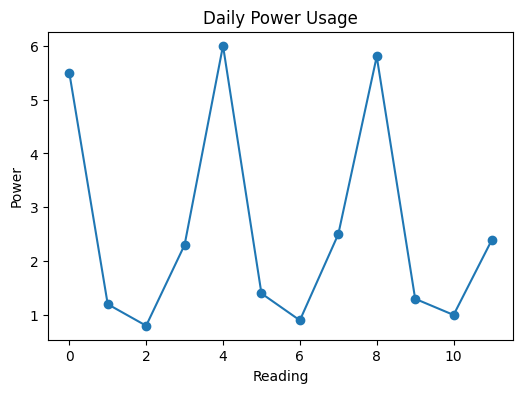

In [ ]:
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# Load Excel file
wb = load_workbook("energy_data.xlsx")
ws = wb.active

appliances = []
power = []

for row in ws.iter_rows(min_row=2, values_only=True):
    appliances.append(row[1])
    power.append(row[2])

        # Bar Chart
plt.figure(figsize=(6,4))
plt.bar(appliances, power)
plt.title("Power Consumption by Appliance")
plt.xlabel("Appliance")
plt.ylabel("Power")
plt.show()

        # Line Chart
plt.figure(figsize=(6,4))
plt.plot(power, marker='o')
plt.title("Daily Power Usage")
plt.xlabel("Reading")
plt.ylabel("Power")
plt.show()

QUESTION 4


Online Learning Platform Performance Analysis
Online learning platforms collect student activity data such as login time, video completion, quiz scores, and assignment submissions. Data preprocessing improves data quality by handling missing values and organizing student performance information. Visualization helps identify student engagement, score distribution, and course completion status. This analysis supports better academic performance monitoring.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving learning_data.xlsx to learning_data.xlsx


In [ ]:
from openpyxl import load_workbook

wb = load_workbook("learning_data.xlsx")
ws = wb.active

students = []

for row in ws.iter_rows(min_row=2, values_only=True):
    students.append((row[1], row[4], row[3]))

students.sort(key=lambda x: x[1] if x[1] is not None else 0, reverse=True)

print("Students Ranked by Quiz Score")
for s in students:
    print(s)

Students Ranked by Quiz Score
('John', 92, 80)
('Ram', 90, 85)
('Ravi', 88, 95)
('Priya', 75, 60)
('Sita', None, 70)


In [ ]:
from openpyxl import load_workbook
from sklearn.impute import SimpleImputer

# Load Excel file
wb = load_workbook("learning_data.xlsx")
ws = wb.active

scores = []

# Collect quiz scores
for row in ws.iter_rows(min_row=2):
    scores.append([row[4].value])

    # Handle missing quiz scores
imputer = SimpleImputer(strategy="mean")
scores = imputer.fit_transform(scores)

print("Student\tQuiz Score\tPerformance")

for i, row in enumerate(ws.iter_rows(min_row=2)):

        # Update quiz score
    row[4].value = float(scores[i][0])

                # Performance Category
    if row[4].value >= 85:
        category = "Excellent"
    elif row[4].value >= 70:
        category = "Good"
    else:
        category = "Average"

print(row[1].value, "\t", row[4].value, "\t", category)

Student	Quiz Score	Performance
John 	 92.0 	 Excellent


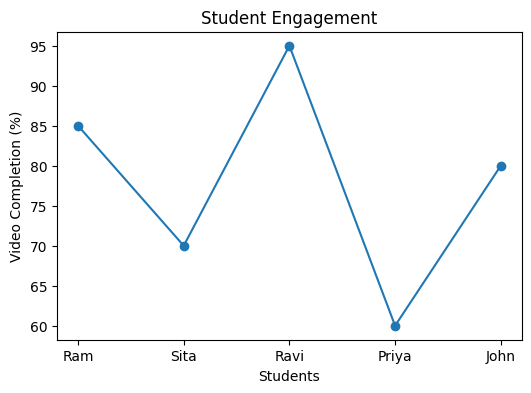

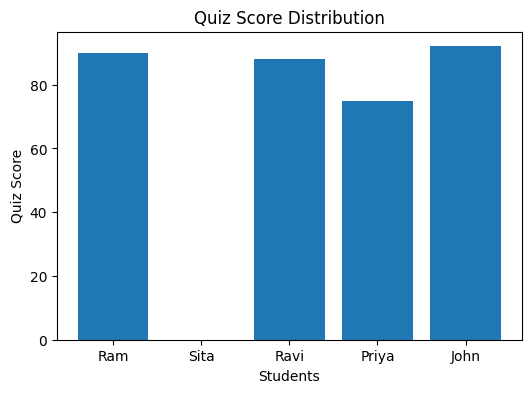

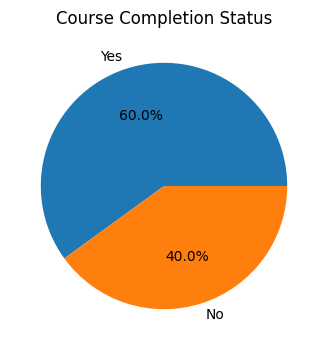

In [ ]:
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# Load Excel file
wb = load_workbook("learning_data.xlsx")
ws = wb.active

students = []
scores = []
completion = []

for row in ws.iter_rows(min_row=2, values_only=True):
    students.append(row[1])
    completion.append(row[3])
    scores.append(0 if row[4] is None else row[4])

            # Student Engagement
plt.figure(figsize=(6,4))
plt.plot(students, completion, marker='o')
plt.title("Student Engagement")
plt.xlabel("Students")
plt.ylabel("Video Completion (%)")
plt.show()

            # Score Distribution
plt.figure(figsize=(6,4))
plt.bar(students, scores)
plt.title("Quiz Score Distribution")
plt.xlabel("Students")
plt.ylabel("Quiz Score")
plt.show()

            # Course Completion Status
status = {"Yes":0, "No":0}

for row in ws.iter_rows(min_row=2, values_only=True):
    status[row[5]] += 1

plt.figure(figsize=(5,4))
plt.pie(status.values(), labels=status.keys(), autopct="%1.1f%%")
plt.title("Course Completion Status")
plt.show()

QUESTION 5


Public Transport Passenger Data Analysis
Public transport departments collect passenger data to improve transportation services. Data analysis identifies busy routes, peak travel hours, and passenger flow patterns. Data preprocessing removes duplicate records and corrects missing or invalid data. Visualization helps transport authorities optimize route planning and reduce overcrowding.

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving transport_data.xlsx to transport_data.xlsx


In [ ]:
from openpyxl import load_workbook

wb = load_workbook("transport_data.xlsx")
ws = wb.active

print("Route\tStop\tTime\tPassengers")

for row in ws.iter_rows(min_row=2, values_only=True):
    print(row[0], "\t", row[1], "\t", row[2], "\t", row[3])

Route	Stop	Time	Passengers
101 	 Central 	 08:00:00 	 45
101 	 Market 	 09:00:00 	 60
102 	 Station 	 08:00:00 	 55
102 	 Hospital 	 09:00:00 	 70
103 	 College 	 10:00:00 	 40
103 	 Mall 	 11:00:00 	 65
104 	 Airport 	 12:00:00 	 80
104 	 Bus Stand 	 13:00:00 	 75


In [ ]:
from openpyxl import load_workbook

# Load Excel file
wb = load_workbook("transport_data.xlsx")
ws = wb.active

seen = set()

for row in ws.iter_rows(min_row=2):

    # Handle missing passenger count
    if row[3].value is None:
        row[3].value = 0

                    # Clean invalid route number
    if row[0].value <= 0:
        row[0].value = 101

                                    # Remove duplicate records
    record = (row[0].value, row[1].value, row[2].value, row[3].value)

    if record in seen:
        ws.delete_rows(row[0].row)
    else:
        seen.add(record)

wb.save("transport_data_cleaned.xlsx")

print("Data Preprocessing Completed")

Data Preprocessing Completed


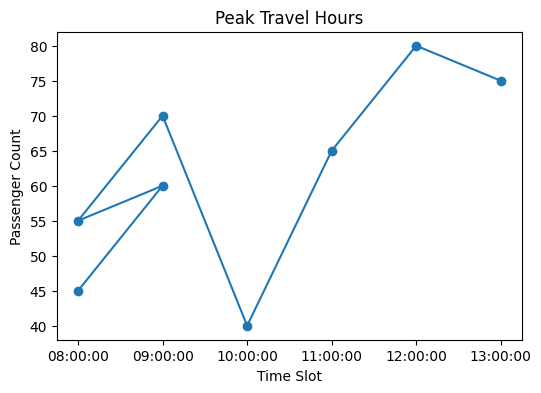

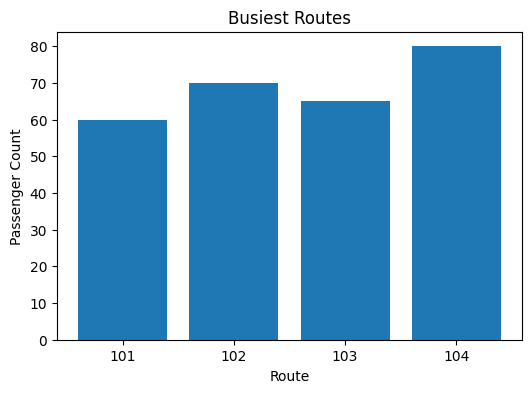

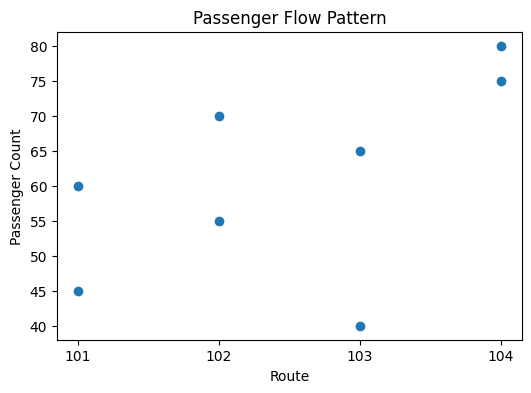

In [ ]:
import matplotlib.pyplot as plt
from openpyxl import load_workbook

# Load Excel file
wb = load_workbook("transport_data.xlsx")
ws = wb.active

routes = []
times = []
passengers = []

for row in ws.iter_rows(min_row=2, values_only=True):
    routes.append(str(row[0]))
    times.append(str(row[2]))
    passengers.append(row[3])

            # Peak Travel Hours
plt.figure(figsize=(6,4))
plt.plot(times, passengers, marker='o')
plt.title("Peak Travel Hours")
plt.xlabel("Time Slot")
plt.ylabel("Passenger Count")
plt.show()

            # Busiest Routes
plt.figure(figsize=(6,4))
plt.bar(routes, passengers)
plt.title("Busiest Routes")
plt.xlabel("Route")
plt.ylabel("Passenger Count")
plt.show()

            # Passenger Flow Pattern
plt.figure(figsize=(6,4))
plt.scatter(routes, passengers)
plt.title("Passenger Flow Pattern")
plt.xlabel("Route")
plt.ylabel("Passenger Count")
plt.show()